АНАЛИЗ ВЛИЯНИЯ ПАРАМЕТРОВ ОПТИМИЗАЦИИ
Вариант 2: Mini-batch Gradient Descent
Сравнение с методом 28: Batch Gradient Descent

Генерация графика: Влияние скорости обучения
Batch GD сошелся на эпохе 202


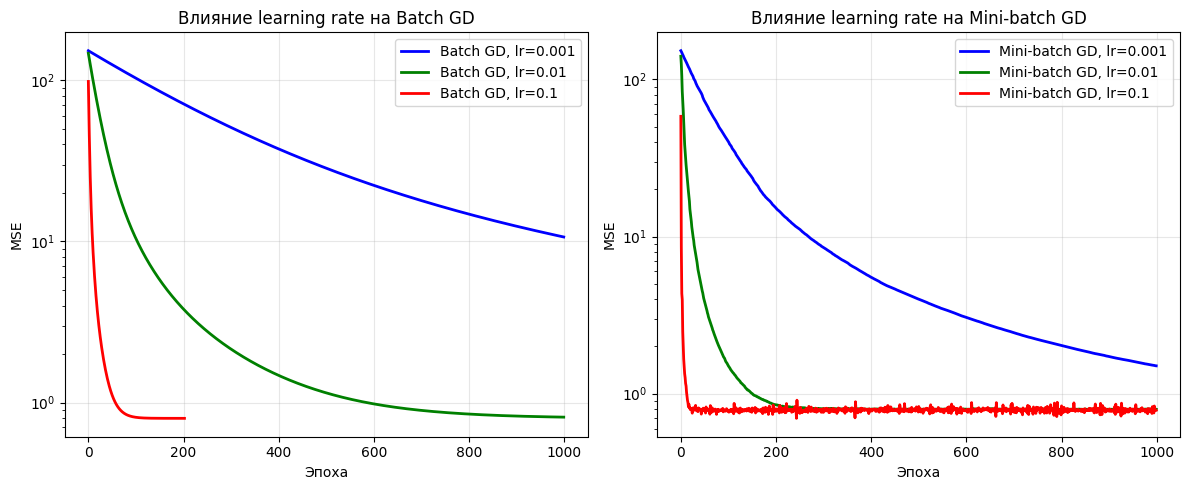

График сохранен: learning_rate_influence.png

Результаты анализа learning rate:
--------------------------------------------------
Batch Gradient Descent:
  lr=0.001: MSE=10.659366, эпох=1000
  lr=0.01: MSE=0.811424, эпох=1000
Batch GD сошелся на эпохе 202
  lr=0.1: MSE=0.797588, эпох=203

Mini-batch Gradient Descent:
  lr=0.001: MSE=1.483543, эпох=1000
Mini-batch GD сошелся на эпохе 797
  lr=0.01: MSE=0.797712, эпох=798
  lr=0.1: MSE=0.798633, эпох=1000

Генерация графика: Влияние начальных параметров
Batch GD сошелся на эпохе 202
Batch GD сошелся на эпохе 201
Batch GD сошелся на эпохе 204


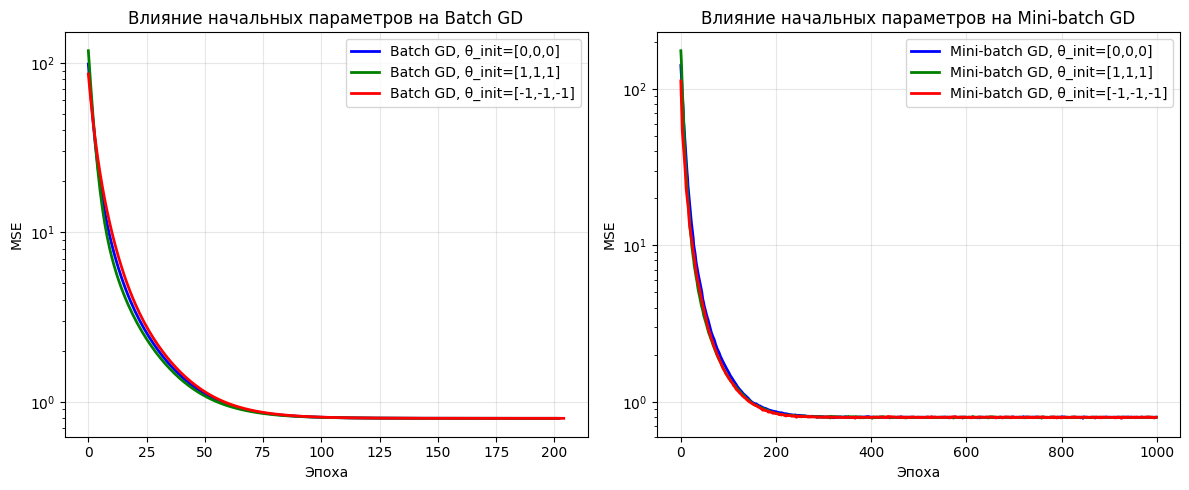

График сохранен: initial_params_influence.png

Результаты анализа начальных параметров:
--------------------------------------------------
Batch Gradient Descent:
Batch GD сошелся на эпохе 202
  θ_init=[0,0,0]: MSE=0.797588, эпох=203
Batch GD сошелся на эпохе 201
  θ_init=[1,1,1]: MSE=0.797587, эпох=202
Batch GD сошелся на эпохе 204
  θ_init=[-1,-1,-1]: MSE=0.797587, эпох=205

Mini-batch Gradient Descent:
  θ_init=[0,0,0]: MSE=0.796613, эпох=1000
Mini-batch GD сошелся на эпохе 797
  θ_init=[1,1,1]: MSE=0.797712, эпох=798
  θ_init=[-1,-1,-1]: MSE=0.796306, эпох=1000

Генерация графика: Влияние количества эпох
Batch GD сошелся на эпохе 202
Batch GD сошелся на эпохе 202
Batch GD сошелся на эпохе 202
Mini-batch GD сошелся на эпохе 473


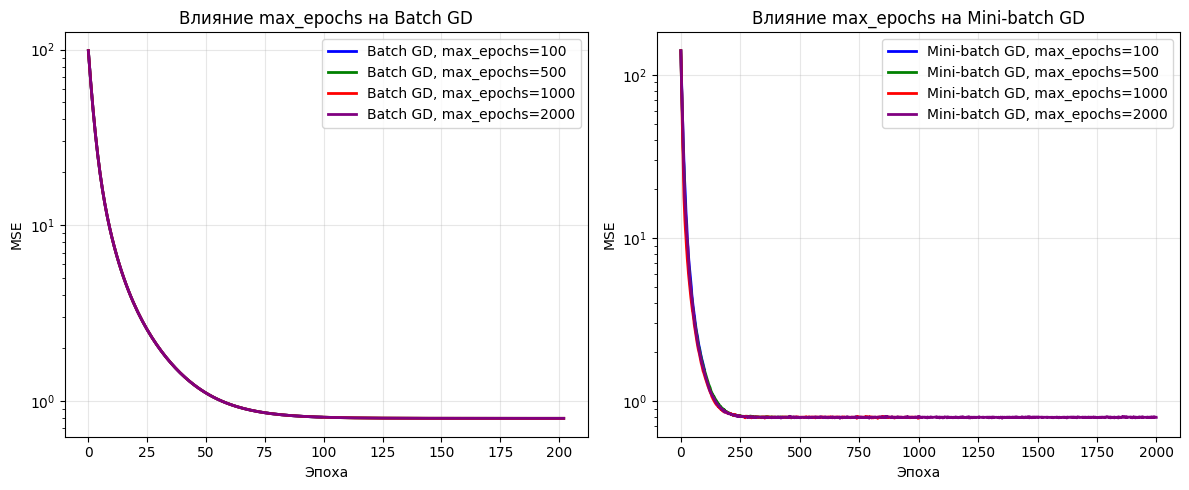

График сохранен: epochs_influence.png

Результаты анализа количества эпох:
--------------------------------------------------
Batch Gradient Descent:
  max_epochs=100: MSE=0.810156, фактически эпох=100
Batch GD сошелся на эпохе 202
  max_epochs=500: MSE=0.797588, фактически эпох=203
Batch GD сошелся на эпохе 202
  max_epochs=1000: MSE=0.797588, фактически эпох=203
Batch GD сошелся на эпохе 202
  max_epochs=2000: MSE=0.797588, фактически эпох=203

Mini-batch Gradient Descent:
  max_epochs=100: MSE=1.445421, фактически эпох=100
  max_epochs=500: MSE=0.798347, фактически эпох=500
Mini-batch GD сошелся на эпохе 395
  max_epochs=1000: MSE=0.797991, фактически эпох=396
Mini-batch GD сошелся на эпохе 559
  max_epochs=2000: MSE=0.796991, фактически эпох=560

Генерация графика: Влияние размера батча
Mini-batch GD сошелся на эпохе 357
Mini-batch GD сошелся на эпохе 610


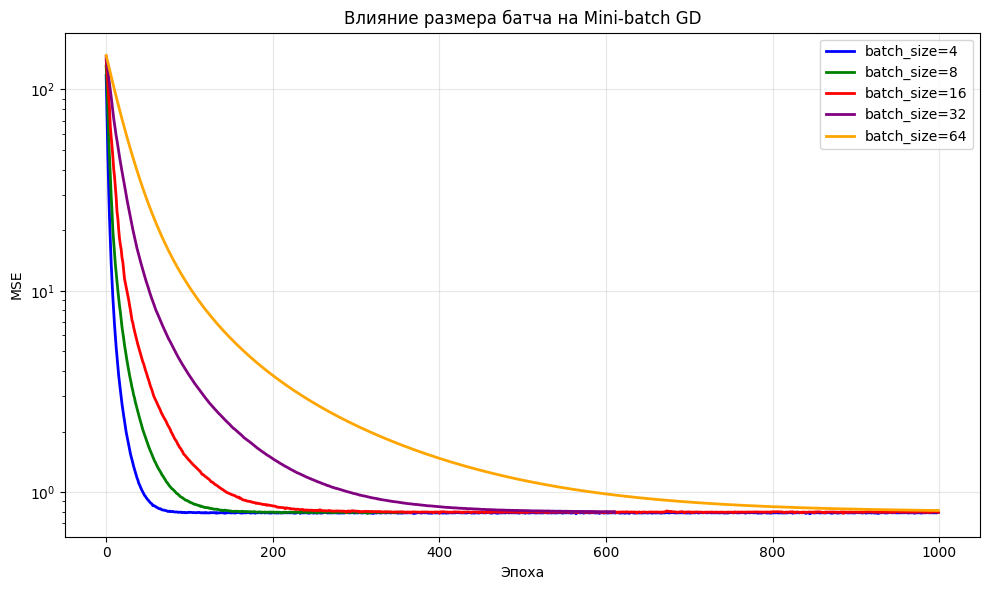

График сохранен: batch_size_influence.png

Результаты анализа размера батча:
--------------------------------------------------
Mini-batch Gradient Descent:
  batch_size=4: MSE=0.793084, эпох=1000
  batch_size=8: MSE=0.793577, эпох=1000
Mini-batch GD сошелся на эпохе 451
  batch_size=16: MSE=0.799399, эпох=452
  batch_size=32: MSE=0.795344, эпох=1000
  batch_size=64: MSE=0.811424, эпох=1000

Генерация графика: Сравнение методов

Обучение Batch Gradient Descent...
Batch GD сошелся на эпохе 202
Обучение Mini-batch Gradient Descent...


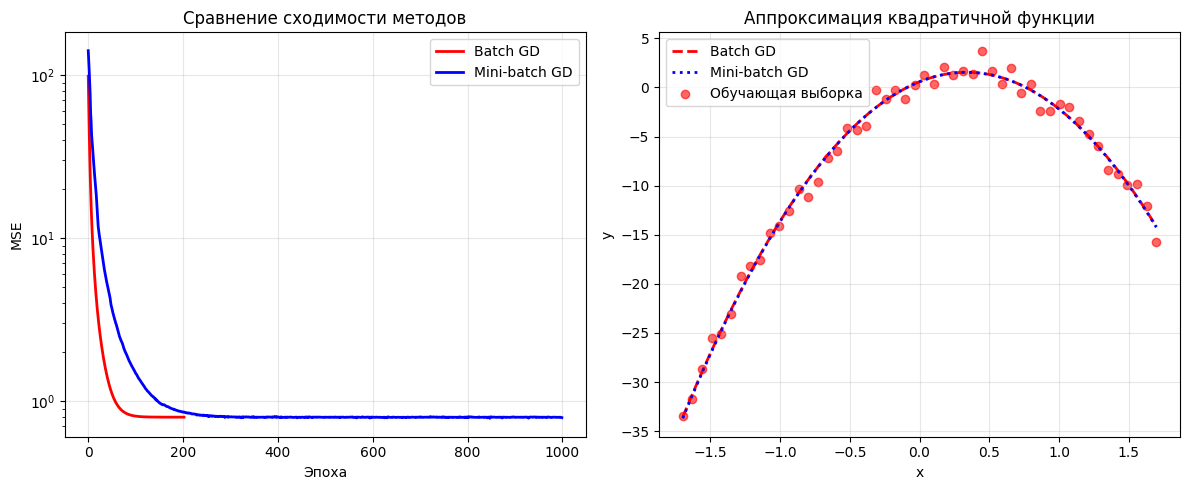

График сохранен: methods_comparison.png

ИТОГОВЫЕ РЕЗУЛЬТАТЫ СРАВНЕНИЯ

Batch Gradient Descent:
  Оптимальные параметры: θ₀=0.5832, θ₁=5.7194, θ₂=-8.4839
  MSE на обучающей выборке: 0.797588
  MSE на тестовой выборке: 4.335189
  Количество эпох: 203

Mini-batch Gradient Descent:
  Оптимальные параметры: θ₀=0.5842, θ₁=5.7314, θ₂=-8.5166
  MSE на обучающей выборке: 0.792521
  MSE на тестовой выборке: 4.153768
  Количество эпох: 1000

Истинные параметры: θ₀=1.0, θ₁=2.0, θ₂=-1.0

АНАЛИЗ ЗАВЕРШЕН!

Созданы следующие графики:
  1. learning_rate_influence.png
  2. initial_params_influence.png
  3. epochs_influence.png
  4. batch_size_influence.png
  5. methods_comparison.png

Эти графики соответствуют примеру из отчета.
Используйте их для раздела 'Анализ влияния параметров'.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List

# =================== ГЕНЕРАЦИЯ ДАННЫХ ===================
def generate_train_data(n_samples: int = 50, noise_level: float = 1.0) -> Tuple[np.ndarray, np.ndarray]:
    """Генерация обучающей выборки с шумом"""
    np.random.seed(42)
    x = np.linspace(-5, 5, n_samples)
    theta_true = [1.0, 2.0, -1.0]  # Истинные параметры
    y = theta_true[0] + theta_true[1] * x + theta_true[2] * x**2 + np.random.normal(0, noise_level, n_samples)
    return x, y, theta_true

def generate_test_data(n_samples: int = 10) -> Tuple[np.ndarray, np.ndarray]:
    """Генерация тестовой выборки без шума"""
    np.random.seed(42)
    x = np.linspace(-5, 5, n_samples)
    theta_true = [1.0, 2.0, -1.0]
    y = theta_true[0] + theta_true[1] * x + theta_true[2] * x**2
    return x, y

def normalize_data(x: np.ndarray) -> np.ndarray:
    """Нормализация данных"""
    return (x - np.mean(x)) / np.std(x)

# =================== МОДЕЛЬ И ГРАДИЕНТЫ ===================
def predict(theta: np.ndarray, x: np.ndarray) -> np.ndarray:
    """Квадратичная модель: f(x) = θ₀ + θ₁x + θ₂x²"""
    return theta[0] + theta[1] * x + theta[2] * x**2

def compute_mse(theta: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    """Вычисление среднеквадратичной ошибки"""
    y_pred = predict(theta, x)
    return np.mean((y_pred - y)**2)

def compute_batch_gradient(theta: np.ndarray, x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Градиент для всей выборки"""
    errors = predict(theta, x) - y
    grad_0 = np.mean(errors)
    grad_1 = np.mean(errors * x)
    grad_2 = np.mean(errors * x**2)
    return np.array([grad_0, grad_1, grad_2])

# =================== МЕТОД 28: BATCH GRADIENT DESCENT ===================
def batch_gradient_descent(x: np.ndarray, y: np.ndarray,
                          theta_init: np.ndarray,
                          learning_rate: float = 0.01,
                          max_epochs: int = 1000,
                          tolerance: float = 1e-6) -> Tuple[np.ndarray, List[float]]:
    """
    Пакетный градиентный спуск
    Градиент вычисляется по всей выборке на каждой итерации
    """
    theta = theta_init.copy()
    loss_history = []

    for epoch in range(max_epochs):
        prev_theta = theta.copy()

        # Вычисление градиента по всей выборке
        gradient = compute_batch_gradient(theta, x, y)

        # Обновление параметров
        theta -= learning_rate * gradient

        # Вычисление MSE
        mse = compute_mse(theta, x, y)
        loss_history.append(mse)

        # Проверка сходимости
        if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < tolerance:
            print(f"Batch GD сошелся на эпохе {epoch}")
            break

    return theta, loss_history

# =================== МЕТОД 2: MINI-BATCH GRADIENT DESCENT ===================
def mini_batch_gradient_descent(x: np.ndarray, y: np.ndarray,
                               theta_init: np.ndarray,
                               learning_rate: float = 0.01,
                               batch_size: int = 32,
                               max_epochs: int = 1000,
                               tolerance: float = 1e-6) -> Tuple[np.ndarray, List[float]]:
    """
    Мини-батч градиентный спуск
    Градиент вычисляется на случайных подвыборках данных
    """
    n_samples = len(x)
    theta = theta_init.copy()
    loss_history = []

    for epoch in range(max_epochs):
        prev_theta = theta.copy()

        # Перемешивание данных
        indices = np.random.permutation(n_samples)
        x_shuffled = x[indices]
        y_shuffled = y[indices]

        epoch_loss = 0

        # Обработка мини-батчей
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            x_batch = x_shuffled[i:end_idx]
            y_batch = y_shuffled[i:end_idx]

            # Градиент на мини-батче
            gradient = compute_batch_gradient(theta, x_batch, y_batch)

            # Обновление параметров
            theta -= learning_rate * gradient

            # Потеря на батче
            batch_loss = compute_mse(theta, x_batch, y_batch)
            epoch_loss += batch_loss * len(x_batch)

        # Средняя потеря за эпоху
        epoch_loss /= n_samples
        loss_history.append(epoch_loss)

        # Проверка сходимости
        if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < tolerance:
            print(f"Mini-batch GD сошелся на эпохе {epoch}")
            break

    return theta, loss_history

# =================== ГРАФИКИ ДЛЯ АНАЛИЗА ПАРАМЕТРОВ ===================

def plot_learning_rate_analysis():
    """График 1: Влияние скорости обучения (как в примере отчета)"""
    print("\nГенерация графика: Влияние скорости обучения")

    # Создаем тестовые данные для анализа
    x_train_raw, y_train_raw, _ = generate_train_data(n_samples=50)
    x_train = normalize_data(x_train_raw)

    # Параметры для анализа
    lr_values_batch = [0.001, 0.01, 0.1]
    lr_values_minibatch = [0.001, 0.01, 0.1]

    # Создаем график
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Batch GD - разные learning rates
    ax1 = axes[0]
    colors = ['blue', 'green', 'red']

    for lr, color in zip(lr_values_batch, colors):
        theta_init = np.array([0.0, 0.0, 0.0])
        theta, loss = batch_gradient_descent(x_train, y_train_raw, theta_init,
                                            learning_rate=lr, max_epochs=1000)
        ax1.plot(loss, color=color, linewidth=2, label=f'Batch GD, lr={lr}')

    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('MSE')
    ax1.set_title('Влияние learning rate на Batch GD')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')

    # 2. Mini-batch GD - разные learning rates
    ax2 = axes[1]

    for lr, color in zip(lr_values_minibatch, colors):
        theta_init = np.array([0.0, 0.0, 0.0])
        theta, loss = mini_batch_gradient_descent(x_train, y_train_raw, theta_init,
                                                 learning_rate=lr, batch_size=16,
                                                 max_epochs=1000)
        ax2.plot(loss, color=color, linewidth=2, label=f'Mini-batch GD, lr={lr}')

    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('MSE')
    ax2.set_title('Влияние learning rate на Mini-batch GD')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')

    plt.tight_layout()
    plt.savefig('learning_rate_influence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("График сохранен: learning_rate_influence.png")

    # Вывод результатов в консоль
    print("\nРезультаты анализа learning rate:")
    print("-" * 50)
    print("Batch Gradient Descent:")
    for lr in lr_values_batch:
        theta_init = np.array([0.0, 0.0, 0.0])
        theta, loss = batch_gradient_descent(x_train, y_train_raw, theta_init,
                                            learning_rate=lr, max_epochs=1000)
        print(f"  lr={lr}: MSE={loss[-1]:.6f}, эпох={len(loss)}")

    print("\nMini-batch Gradient Descent:")
    for lr in lr_values_minibatch:
        theta_init = np.array([0.0, 0.0, 0.0])
        theta, loss = mini_batch_gradient_descent(x_train, y_train_raw, theta_init,
                                                 learning_rate=lr, batch_size=16,
                                                 max_epochs=1000)
        print(f"  lr={lr}: MSE={loss[-1]:.6f}, эпох={len(loss)}")

def plot_initial_params_analysis():
    """График 2: Влияние начальных параметров (как в примере отчета)"""
    print("\nГенерация графика: Влияние начальных параметров")

    # Создаем тестовые данные для анализа
    x_train_raw, y_train_raw, _ = generate_train_data(n_samples=50)
    x_train = normalize_data(x_train_raw)

    # Разные начальные параметры
    initial_params = [
        [0.0, 0.0, 0.0],
        [1.0, 1.0, 1.0],
        [-1.0, -1.0, -1.0]
    ]
    labels = ['[0,0,0]', '[1,1,1]', '[-1,-1,-1]']
    colors = ['blue', 'green', 'red']

    # Создаем график
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Batch GD - разные начальные параметры
    ax1 = axes[0]

    for params, color, label in zip(initial_params, colors, labels):
        theta, loss = batch_gradient_descent(x_train, y_train_raw, np.array(params),
                                            learning_rate=0.1, max_epochs=1000)
        ax1.plot(loss, color=color, linewidth=2, label=f'Batch GD, θ_init={label}')

    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('MSE')
    ax1.set_title('Влияние начальных параметров на Batch GD')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')

    # 2. Mini-batch GD - разные начальные параметры
    ax2 = axes[1]

    for params, color, label in zip(initial_params, colors, labels):
        theta, loss = mini_batch_gradient_descent(x_train, y_train_raw, np.array(params),
                                                 learning_rate=0.01, batch_size=16,
                                                 max_epochs=1000)
        ax2.plot(loss, color=color, linewidth=2, label=f'Mini-batch GD, θ_init={label}')

    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('MSE')
    ax2.set_title('Влияние начальных параметров на Mini-batch GD')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')

    plt.tight_layout()
    plt.savefig('initial_params_influence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("График сохранен: initial_params_influence.png")

    # Вывод результатов в консоль
    print("\nРезультаты анализа начальных параметров:")
    print("-" * 50)
    print("Batch Gradient Descent:")
    for params, label in zip(initial_params, labels):
        theta, loss = batch_gradient_descent(x_train, y_train_raw, np.array(params),
                                            learning_rate=0.1, max_epochs=1000)
        print(f"  θ_init={label}: MSE={loss[-1]:.6f}, эпох={len(loss)}")

    print("\nMini-batch Gradient Descent:")
    for params, label in zip(initial_params, labels):
        theta, loss = mini_batch_gradient_descent(x_train, y_train_raw, np.array(params),
                                                 learning_rate=0.01, batch_size=16,
                                                 max_epochs=1000)
        print(f"  θ_init={label}: MSE={loss[-1]:.6f}, эпох={len(loss)}")

def plot_epochs_analysis():
    """График 3: Влияние количества эпох (как в примере отчета)"""
    print("\nГенерация графика: Влияние количества эпох")

    # Создаем тестовые данные для анализа
    x_train_raw, y_train_raw, _ = generate_train_data(n_samples=50)
    x_train = normalize_data(x_train_raw)

    # Разные значения max_epochs
    max_epochs_values = [100, 500, 1000, 2000]
    colors = ['blue', 'green', 'red', 'purple']

    # Создаем график
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Batch GD - разные max_epochs
    ax1 = axes[0]

    for max_epochs, color in zip(max_epochs_values, colors):
        theta_init = np.array([0.0, 0.0, 0.0])
        theta, loss = batch_gradient_descent(x_train, y_train_raw, theta_init,
                                            learning_rate=0.1, max_epochs=max_epochs)
        ax1.plot(loss, color=color, linewidth=2, label=f'Batch GD, max_epochs={max_epochs}')

    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('MSE')
    ax1.set_title('Влияние max_epochs на Batch GD')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')

    # 2. Mini-batch GD - разные max_epochs
    ax2 = axes[1]

    for max_epochs, color in zip(max_epochs_values, colors):
        theta_init = np.array([0.0, 0.0, 0.0])
        theta, loss = mini_batch_gradient_descent(x_train, y_train_raw, theta_init,
                                                 learning_rate=0.01, batch_size=16,
                                                 max_epochs=max_epochs)
        ax2.plot(loss, color=color, linewidth=2, label=f'Mini-batch GD, max_epochs={max_epochs}')

    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('MSE')
    ax2.set_title('Влияние max_epochs на Mini-batch GD')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_yscale('log')

    plt.tight_layout()
    plt.savefig('epochs_influence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("График сохранен: epochs_influence.png")

    # Вывод результатов в консоль
    print("\nРезультаты анализа количества эпох:")
    print("-" * 50)
    print("Batch Gradient Descent:")
    for max_epochs in max_epochs_values:
        theta_init = np.array([0.0, 0.0, 0.0])
        theta, loss = batch_gradient_descent(x_train, y_train_raw, theta_init,
                                            learning_rate=0.1, max_epochs=max_epochs)
        print(f"  max_epochs={max_epochs}: MSE={loss[-1]:.6f}, фактически эпох={len(loss)}")

    print("\nMini-batch Gradient Descent:")
    for max_epochs in max_epochs_values:
        theta_init = np.array([0.0, 0.0, 0.0])
        theta, loss = mini_batch_gradient_descent(x_train, y_train_raw, theta_init,
                                                 learning_rate=0.01, batch_size=16,
                                                 max_epochs=max_epochs)
        print(f"  max_epochs={max_epochs}: MSE={loss[-1]:.6f}, фактически эпох={len(loss)}")

def plot_batch_size_analysis():
    """График 4: Влияние размера батча (только для Mini-batch GD)"""
    print("\nГенерация графика: Влияние размера батча")

    # Создаем тестовые данные для анализа
    x_train_raw, y_train_raw, _ = generate_train_data(n_samples=50)
    x_train = normalize_data(x_train_raw)

    # Разные размеры батча
    batch_sizes = [4, 8, 16, 32, 64]
    colors = ['blue', 'green', 'red', 'purple', 'orange']

    # Создаем график
    plt.figure(figsize=(10, 6))

    for batch_size, color in zip(batch_sizes, colors):
        theta_init = np.array([0.0, 0.0, 0.0])
        theta, loss = mini_batch_gradient_descent(x_train, y_train_raw, theta_init,
                                                 learning_rate=0.01, batch_size=batch_size,
                                                 max_epochs=1000)
        plt.plot(loss, color=color, linewidth=2, label=f'batch_size={batch_size}')

    plt.xlabel('Эпоха')
    plt.ylabel('MSE')
    plt.title('Влияние размера батча на Mini-batch GD')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')

    plt.tight_layout()
    plt.savefig('batch_size_influence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("График сохранен: batch_size_influence.png")

    # Вывод результатов в консоль
    print("\nРезультаты анализа размера батча:")
    print("-" * 50)
    print("Mini-batch Gradient Descent:")
    for batch_size in batch_sizes:
        theta_init = np.array([0.0, 0.0, 0.0])
        theta, loss = mini_batch_gradient_descent(x_train, y_train_raw, theta_init,
                                                 learning_rate=0.01, batch_size=batch_size,
                                                 max_epochs=1000)
        print(f"  batch_size={batch_size}: MSE={loss[-1]:.6f}, эпох={len(loss)}")

def plot_comparison():
    """График 5: Сравнение методов"""
    print("\nГенерация графика: Сравнение методов")

    # Создаем тестовые данные
    x_train_raw, y_train_raw, theta_true = generate_train_data(n_samples=50)
    x_train = normalize_data(x_train_raw)

    # Генерация тестовых данных
    x_test_raw, y_test_raw = generate_test_data(n_samples=10)
    x_test = normalize_data(x_test_raw)

    # Обучение Batch GD
    print("\nОбучение Batch Gradient Descent...")
    theta_init = np.array([0.0, 0.0, 0.0])
    theta_batch, loss_batch = batch_gradient_descent(x_train, y_train_raw, theta_init,
                                                    learning_rate=0.1, max_epochs=2000)

    # Обучение Mini-batch GD
    print("Обучение Mini-batch Gradient Descent...")
    theta_minibatch, loss_minibatch = mini_batch_gradient_descent(x_train, y_train_raw, theta_init,
                                                                 learning_rate=0.01, batch_size=16,
                                                                 max_epochs=1000)

    # Создаем график сравнения
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Сравнение сходимости
    ax1 = axes[0]
    ax1.plot(loss_batch, 'r-', linewidth=2, label='Batch GD')
    ax1.plot(loss_minibatch, 'b-', linewidth=2, label='Mini-batch GD')
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('MSE')
    ax1.set_title('Сравнение сходимости методов')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')

    # 2. Аппроксимация функции
    ax2 = axes[1]

    # Гладкая кривая для отображения функций
    x_curve = np.linspace(min(x_train), max(x_train), 200)

    # Batch GD
    y_batch = predict(theta_batch, x_curve)
    ax2.plot(x_curve, y_batch, 'r--', linewidth=2, label='Batch GD')

    # Mini-batch GD
    y_minibatch = predict(theta_minibatch, x_curve)
    ax2.plot(x_curve, y_minibatch, 'b:', linewidth=2, label='Mini-batch GD')

    # Данные
    ax2.scatter(x_train, y_train_raw, color='red', alpha=0.6, label='Обучающая выборка')

    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('Аппроксимация квадратичной функции')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('methods_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("График сохранен: methods_comparison.png")

    # Вывод итоговых результатов
    mse_test_batch = compute_mse(theta_batch, x_test, y_test_raw)
    mse_test_minibatch = compute_mse(theta_minibatch, x_test, y_test_raw)

    print("\n" + "="*60)
    print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
    print("="*60)
    print(f"\nBatch Gradient Descent:")
    print(f"  Оптимальные параметры: θ₀={theta_batch[0]:.4f}, θ₁={theta_batch[1]:.4f}, θ₂={theta_batch[2]:.4f}")
    print(f"  MSE на обучающей выборке: {loss_batch[-1]:.6f}")
    print(f"  MSE на тестовой выборке: {mse_test_batch:.6f}")
    print(f"  Количество эпох: {len(loss_batch)}")

    print(f"\nMini-batch Gradient Descent:")
    print(f"  Оптимальные параметры: θ₀={theta_minibatch[0]:.4f}, θ₁={theta_minibatch[1]:.4f}, θ₂={theta_minibatch[2]:.4f}")
    print(f"  MSE на обучающей выборке: {loss_minibatch[-1]:.6f}")
    print(f"  MSE на тестовой выборке: {mse_test_minibatch:.6f}")
    print(f"  Количество эпох: {len(loss_minibatch)}")

    print(f"\nИстинные параметры: θ₀={theta_true[0]}, θ₁={theta_true[1]}, θ₂={theta_true[2]}")
    print("="*60)

# =================== ОСНОВНАЯ ФУНКЦИЯ ===================
def main():
    print("=" * 60)
    print("АНАЛИЗ ВЛИЯНИЯ ПАРАМЕТРОВ ОПТИМИЗАЦИИ")
    print("Вариант 2: Mini-batch Gradient Descent")
    print("Сравнение с методом 28: Batch Gradient Descent")
    print("=" * 60)

    # Генерация всех графиков
    plot_learning_rate_analysis()
    plot_initial_params_analysis()
    plot_epochs_analysis()
    plot_batch_size_analysis()
    plot_comparison()

    print("\n" + "=" * 60)
    print("АНАЛИЗ ЗАВЕРШЕН!")
    print("\nСозданы следующие графики:")
    print("  1. learning_rate_influence.png")
    print("  2. initial_params_influence.png")
    print("  3. epochs_influence.png")
    print("  4. batch_size_influence.png")
    print("  5. methods_comparison.png")
    print("\nЭти графики соответствуют примеру из отчета.")
    print("Используйте их для раздела 'Анализ влияния параметров'.")
    print("=" * 60)

if __name__ == "__main__":
    main()

